# Ukrainian Speech Recognition Pipeline — Whisper Fine-Tuning on Toronto Dataset

This notebook implements a complete end-to-end pipeline for Ukrainian speech recognition:
- **Model**: `openai/whisper-small` (HuggingFace)
- **Training framework**: PyTorch Lightning
- **Dataset**: Toronto Ukrainian Speech Dataset
- **Metrics**: WER (Word Error Rate) and CER (Character Error Rate)


---
## Part 1 — Training Pipeline


### 1.1 Install Required Libraries

In [ ]:
!pip install transformers datasets pytorch-lightning evaluate matplotlib numpy torch soundfile jiwer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.9 MB/s eta 0:00:00


### 1.2 Imports & Utility Functions

In [ ]:
import os
import re
import json
import logging
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union

import torch
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint, EarlyStopping, LearningRateMonitor
)
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader, Dataset
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
import evaluate
from datasets import load_dataset, Audio
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import soundfile

def load_audio(path):
    audio, sr = soundfile.read(path)
    if len(audio.shape) > 1:
        audio = audio[:, 0]
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    return audio


### 1.3 Load and Analyze the Toronto Ukrainian Speech Dataset

Load the Toronto Ukrainian Speech dataset from Kaggle and preload all audio into RAM for efficient training.


In [ ]:
import json
from pathlib import Path
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

logger.info('Loading Toronto dataset metadata ...')

data_dir = Path('/kaggle/input/datasets/dmytromalykpn/toronto-data')
labels_file = str(data_dir / 'labels.jsonl')

raw_samples = []
with open(labels_file, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        for audio_path, transcription in data.items():
            if audio_path.startswith('dataset/'):
                audio_path = audio_path[8:]
            audio_file = data_dir / audio_path
            if audio_file.exists():
                audio_id = audio_file.stem
                raw_samples.append({
                    'id': audio_id,
                    'sentence': transcription,
                    'audio_path': str(audio_file)
                })

logger.info(f'Found {len(raw_samples)} samples on disk. Preloading audio into RAM...')

samples = []
failed = 0
for s in tqdm(raw_samples):
    try:
        audio_array = load_audio(s['audio_path'])
        samples.append({
            'id': s['id'],
            'sentence': s['sentence'],
            'audio_array': audio_array,
        })
    except Exception as e:
        failed += 1
        logger.warning(f"Failed to load {s['id']}: {e}")

logger.info(f'Preloaded {len(samples)} samples into RAM, failed {failed}.')
ds = samples
print(f'Dataset ready with {len(ds)} samples (all in RAM).')


INFO:__main__:Loading Toronto dataset metadata ...
INFO:__main__:Found 18303 samples on disk. Preloading audio into RAM...
100%|██████████| 18303/18303 [05:14<00:00, 58.28it/s]
INFO:__main__:Preloaded 18303 samples into RAM, failed 0.


Dataset ready with 18303 samples (all in RAM).


### 1.4 Preprocess and Visualize Dataset Statistics

INFO:__main__:Total: 18303 | Train+Val: 12761 | Test: 5542
INFO:__main__:Successfully processed 100 samples, failed 0
INFO:__main__:Duration – mean: 6.12s  std: 1.03s  min: 2.71s  max: 8.38s
INFO:__main__:Words/utt – mean: 14.1  max: 37
INFO:__main__:Chars/utt – mean: 92.1  max: 304
INFO:__main__:Unique words: 904 | Total tokens: 1397
INFO:__main__:Unique chars: 76


Sample id: toronto_145_0


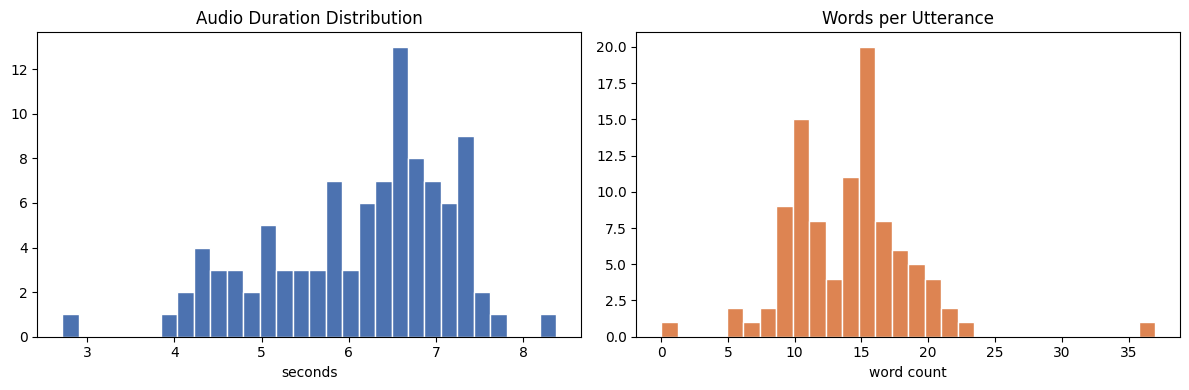

INFO:__main__:Plots saved to outputs/eda_plots.png
INFO:__main__:{
  "total_samples": 18303,
  "train_val": 12761,
  "test": 5542,
  "duration_mean_sec": 6.12,
  "duration_std_sec": 1.03,
  "duration_max_sec": 8.38,
  "words_per_utt_mean": 14.1,
  "chars_per_utt_mean": 92.1,
  "unique_words": 904,
  "unique_chars": 76
}


In [ ]:
TEST_DIRS = {
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
    'toronto_58',
}

def get_dir_from_id(sample_id):
    return '_'.join(sample_id.split('_')[:2])

def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^\w\s']", '', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

total = len(ds)
train_val_samples = [s for s in ds if get_dir_from_id(s['id']) not in TEST_DIRS]
test_samples = [s for s in ds if get_dir_from_id(s['id']) in TEST_DIRS]

logger.info(f'Total: {total} | Train+Val: {len(train_val_samples)} | Test: {len(test_samples)}')

if len(train_val_samples) > 0:
    print(f"Sample id: {train_val_samples[0]['id']}")

import random
random.seed(42)
sample_size = min(100, len(train_val_samples))
sampled_indices = random.sample(range(len(train_val_samples)), sample_size) if len(train_val_samples) > 0 else []

durations = []
texts = []
failed_count = 0
for idx in sampled_indices:
    try:
        sample = train_val_samples[idx]
        durations.append(len(sample['audio_array']) / 16_000)
        texts.append(sample['sentence'])
    except Exception as e:
        failed_count += 1
        if failed_count <= 3:
            logger.warning(f"Failed to process {sample['id']}: {e}")

logger.info(f'Successfully processed {len(durations)} samples, failed {failed_count}')

if len(durations) > 0:
    logger.info(f"Duration – mean: {np.mean(durations):.2f}s  std: {np.std(durations):.2f}s  "
                f"min: {np.min(durations):.2f}s  max: {np.max(durations):.2f}s")

    words = [len(t.split()) for t in texts]
    chars = [len(t) for t in texts]
    logger.info(f"Words/utt – mean: {np.mean(words):.1f}  max: {np.max(words)}")
    logger.info(f"Chars/utt – mean: {np.mean(chars):.1f}  max: {np.max(chars)}")

    all_words = ' '.join(texts).lower()
    all_words = re.sub(r"[^\w\s']", '', all_words, flags=re.UNICODE)
    word_list = all_words.split()
    vocab = Counter(word_list)
    logger.info(f"Unique words: {len(vocab)} | Total tokens: {len(word_list)}")

    all_chars = set(''.join(texts).lower())
    logger.info(f"Unique chars: {len(all_chars)}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(durations, bins=30, color='#4C72B0', edgecolor='white')
    axes[0].set_title('Audio Duration Distribution'); axes[0].set_xlabel('seconds')
    axes[1].hist(words, bins=30, color='#DD8452', edgecolor='white')
    axes[1].set_title('Words per Utterance'); axes[1].set_xlabel('word count')
    plt.tight_layout()
    Path('outputs').mkdir(exist_ok=True)
    plt.savefig('outputs/eda_plots.png', dpi=150)
    plt.show()
    logger.info('Plots saved to outputs/eda_plots.png')

    stats = {
        'total_samples': total,
        'train_val': len(train_val_samples),
        'test': len(test_samples),
        'duration_mean_sec': round(float(np.mean(durations)), 2),
        'duration_std_sec': round(float(np.std(durations)), 2),
        'duration_max_sec': round(float(np.max(durations)), 2),
        'words_per_utt_mean': round(float(np.mean(words)), 1),
        'chars_per_utt_mean': round(float(np.mean(chars)), 1),
        'unique_words': len(vocab),
        'unique_chars': len(all_chars),
    }
    with open('outputs/eda_stats.json', 'w') as f:
        json.dump(stats, f, indent=2)
    logger.info(json.dumps(stats, indent=2))
else:
    logger.error('No samples could be loaded. Check audio file paths.')


### 1.5 Prepare Data Splits (Train / Val / Test)

In [ ]:
train_val_samples = [s for s in ds if get_dir_from_id(s['id']) not in TEST_DIRS]
test_samples = [s for s in ds if get_dir_from_id(s['id']) in TEST_DIRS]

split = int(0.9 * len(train_val_samples))
train_samples = train_val_samples[:split]
val_samples = train_val_samples[split:]

print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')


Train: 11484 | Val: 1277 | Test: 5542


### 1.6 Select and Load Pretrained Whisper Model

We use `openai/whisper-small` — a balanced choice between accuracy and training speed for a Ukrainian fine-tuning task on a single GPU.

In [ ]:
model_name = 'openai/whisper-small'
language   = 'ukrainian'
task       = 'transcribe'

processor = WhisperProcessor.from_pretrained(model_name, language=language, task=task)
model     = WhisperForConditionalGeneration.from_pretrained(model_name)

model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language=language, task=task
)

print('Pretrained Whisper model loaded.')


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Pretrained Whisper model loaded.


### 1.7 PyTorch Lightning DataModule

In [ ]:
class TorontoDataset(Dataset):
    def __init__(self, samples: List[Dict], processor: WhisperProcessor, max_len: int = 480_000):
        self.samples = samples
        self.processor = processor
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self._get_single_item(idx)

    def _get_single_item(self, idx):
        item = self.samples[idx]

        audio_array = item['audio_array']
        if len(audio_array) > self.max_len:
            audio_array = audio_array[:self.max_len]

        input_features = self.processor(
            audio_array, sampling_rate=16_000, return_tensors='pt'
        ).input_features[0]

        label_ids = self.processor.tokenizer(
            normalize_text(item['sentence']),
            return_tensors='pt',
        ).input_ids[0]

        return {'input_features': input_features, 'labels': label_ids}


def collate_fn(batch, processor):
    input_features = [{'input_features': b['input_features']} for b in batch]
    label_batch = [{'input_ids': b['labels']} for b in batch]

    batch_feats = processor.feature_extractor.pad(input_features, return_tensors='pt')
    labels = processor.tokenizer.pad(label_batch, return_tensors='pt')
    label_ids = labels['input_ids'].masked_fill(labels['attention_mask'].ne(1), -100)

    if (label_ids[:, 0] == processor.tokenizer.bos_token_id).all():
        label_ids = label_ids[:, 1:]

    return {'input_features': batch_feats['input_features'], 'labels': label_ids}


class TorontoDataModule(pl.LightningDataModule):
    def __init__(self, cfg, train_samples, val_samples, test_samples):
        super().__init__()
        self.cfg = cfg
        self.train_samples = train_samples
        self.val_samples = val_samples
        self.test_samples = test_samples
        self.processor = WhisperProcessor.from_pretrained(
            cfg.model_name, language=cfg.language, task=cfg.task
        )

    def setup(self, stage=None):
        self.train_data = TorontoDataset(self.train_samples, self.processor)
        self.val_data = TorontoDataset(self.val_samples, self.processor)
        self.test_data = TorontoDataset(self.test_samples, self.processor)
        logger.info(f'DataModule setup: Train: {len(self.train_data)} | Val: {len(self.val_data)} | Test: {len(self.test_data)}')

    def _loader(self, dataset, shuffle=False):
        return DataLoader(
            dataset, batch_size=self.cfg.batch_size, shuffle=shuffle,
            num_workers=4, pin_memory=True,
            collate_fn=lambda b: collate_fn(b, self.processor),
        )

    def train_dataloader(self): return self._loader(self.train_data, shuffle=True)
    def val_dataloader(self): return self._loader(self.val_data)
    def test_dataloader(self): return self._loader(self.test_data)


### 1.8 PyTorch Lightning Training Module (WhisperLightningModule)

In [ ]:
class WhisperLightningModule(pl.LightningModule):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.save_hyperparameters()

        self.model     = WhisperForConditionalGeneration.from_pretrained(cfg.model_name)
        self.processor = WhisperProcessor.from_pretrained(
            cfg.model_name, language=cfg.language, task=cfg.task
        )
        self.model.generation_config.forced_decoder_ids = (
            self.processor.get_decoder_prompt_ids(language=cfg.language, task=cfg.task)
        )

        self.model.train()
        self.model.model.encoder.eval()
        for p in self.model.model.encoder.parameters():
            p.requires_grad = False

        self.wer_metric = evaluate.load("wer")
        self.cer_metric = evaluate.load("cer")

    def forward(self, input_features, labels=None):
        return self.model(input_features=input_features, labels=labels)

    def _step(self, batch):
        out = self(batch["input_features"], batch["labels"])
        return out.loss

    def training_step(self, batch, _):
        loss = self._step(batch)
        self.log("train/loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        loss = self._step(batch)
        preds, refs = self._decode(batch)
        wer = self.wer_metric.compute(predictions=preds, references=refs)
        cer = self.cer_metric.compute(predictions=preds, references=refs)
        self.log_dict({"val/loss": loss, "val/wer": wer, "val/cer": cer},
                      prog_bar=True, on_epoch=True)

    def test_step(self, batch, _):
        loss = self._step(batch)
        preds, refs = self._decode(batch)
        wer = self.wer_metric.compute(predictions=preds, references=refs)
        cer = self.cer_metric.compute(predictions=preds, references=refs)
        self.log_dict({"test/loss": loss, "test/wer": wer, "test/cer": cer})
        return {"predictions": preds, "references": refs}

    def _decode(self, batch):
        with torch.no_grad():
            gen = self.model.generate(batch["input_features"])
        preds    = self.processor.batch_decode(gen, skip_special_tokens=True)
        refs_ids = batch["labels"].clone()
        refs_ids[refs_ids == -100] = self.processor.tokenizer.pad_token_id
        refs  = self.processor.batch_decode(refs_ids, skip_special_tokens=True)
        preds = [normalize_text(p) for p in preds]
        refs  = [normalize_text(r) for r in refs]
        return preds, refs

    def configure_optimizers(self):
        no_decay = {"bias", "LayerNorm.weight"}
        params = [
            {"params": [p for n, p in self.named_parameters()
                        if not any(nd in n for nd in no_decay) and p.requires_grad],
             "weight_decay": self.cfg.weight_decay},
            {"params": [p for n, p in self.named_parameters()
                        if any(nd in n for nd in no_decay) and p.requires_grad],
             "weight_decay": 0.0},
        ]
        opt         = torch.optim.AdamW(params, lr=self.cfg.learning_rate)
        total_steps = self.trainer.estimated_stepping_batches
        sched       = get_linear_schedule_with_warmup(opt, self.cfg.warmup_steps, total_steps)
        return {
            "optimizer": opt,
            "lr_scheduler": {"scheduler": sched, "interval": "step",
                             "frequency": 1, "strict": True},
        }


### 1.9 Configuration, Callbacks, and Logger

In [ ]:
from pytorch_lightning.callbacks import Callback

class SaveToOutputCallback(Callback):
    def on_train_end(self, trainer, pl_module):
        save_path = '/kaggle/working/whisper-ukrainian/final_model'
        os.makedirs(save_path, exist_ok=True)
        pl_module.model.save_pretrained(save_path)
        pl_module.processor.save_pretrained(save_path)
        print(f'Model saved to {save_path}')

@dataclass
class Config:
    model_name:   str   = 'openai/whisper-small'
    language:     str   = 'ukrainian'
    task:         str   = 'transcribe'
    dataset_name: str   = 'Yehor/toronto-dataset'
    sampling_rate: int  = 16_000
    test_lines: List[str] = field(default_factory=lambda: [
        'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
        'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
        'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
        'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
        'toronto_58',
    ])
    batch_size:     int   = 32
    grad_accum:     int   = 1
    max_epochs:     int   = 8
    learning_rate:  float = 5e-5
    warmup_steps:   int   = 100
    weight_decay:   float = 0.01
    max_audio_len_sec: float = 30.0
    fp16:           bool  = True
    output_dir:     str   = '/kaggle/working/whisper-ukrainian/outputs'
    checkpoint_dir: str   = '/kaggle/working/whisper-ukrainian/checkpoints'

CFG = Config()

callbacks = [
    ModelCheckpoint(
        dirpath=CFG.checkpoint_dir,
        filename='whisper-toronto-{epoch:02d}-{val/wer:.4f}',
        monitor='val/wer', mode='min', save_top_k=1,
    ),
    EarlyStopping(monitor='val/wer', patience=2, mode='min'),
    LearningRateMonitor(logging_interval='step'),
    SaveToOutputCallback(),
]

logger_tb = TensorBoardLogger('tb_logs', name='whisper_toronto')
print('Config and callbacks initialized.')


Config and callbacks initialized.


### 1.10 Train the Whisper Model

In [ ]:
pl.seed_everything(42)
os.makedirs(CFG.output_dir,     exist_ok=True)
os.makedirs(CFG.checkpoint_dir, exist_ok=True)

dm = TorontoDataModule(CFG, train_samples, val_samples, test_samples)
lm = WhisperLightningModule(CFG)

trainer = pl.Trainer(
    max_epochs=CFG.max_epochs,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    precision='16-mixed' if CFG.fp16 else 32,
    accumulate_grad_batches=CFG.grad_accum,
    callbacks=callbacks,
    logger=logger_tb,
    log_every_n_steps=10,
    gradient_clip_val=1.0,
    val_check_interval=1.0,
)

trainer.fit(lm, dm)
print('Training complete.')


Seed set to 42


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
2026-04-24 09:11:35.536670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777021896.110836      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777021896.250376      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has 

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ WhisperForConditionalGeneration │  241 M │ train │     0 │
└───┴───────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 153 M                                                                                            
Non-trainable params: 88.2 M                                                                                       
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 212                                                                                         
Modules in eval mode: 138                                                                                          
Total FLOPs: 0

Output()

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 138 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of 
`lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite 
order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the 
first value of the learning rate schedule. See more details at 
https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

### 1.11 Save the Fine-Tuned Model

In [ ]:
lm.model.save_pretrained(os.path.join(CFG.output_dir, 'final_model'))
lm.processor.save_pretrained(os.path.join(CFG.output_dir, 'final_model'))
print(f'Model saved to {CFG.output_dir}/final_model')


Model saved to /kaggle/working/whisper-ukrainian/outputs/final_model


---
## Part 2 — Evaluation on Held-Out Test Set


### 2.1 Install Libraries (Evaluation Environment)

In [ ]:
!pip install -q transformers pytorch-lightning evaluate soundfile jiwer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.8 MB/s eta 0:00:00



### 2.2 Imports & Helpers

In [ ]:
import os, re, json, logging
from pathlib import Path
from typing import List, Dict

import torch
import numpy as np
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import evaluate
import soundfile
from tqdm import tqdm

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_audio(path):
    audio, sr = soundfile.read(path)
    if len(audio.shape) > 1:
        audio = audio[:, 0]
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    return audio

def normalize_text(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^\w\s']", '', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Imports done.')


Imports done.


### 2.3 Verify Model Output Path

In [ ]:
model_path = '/kaggle/input/datasets/dmytromalykpn/output/whisper-ukrainian/final_model'

print('Files in model directory:')
for f in os.listdir(model_path):
    print(f'  {f}')


Files in model directory:
  config.json
  tokenizer.json
  tokenizer_config.json
  model.safetensors
  processor_config.json
  generation_config.json


### 2.4 Load Fine-Tuned Model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

model     = WhisperForConditionalGeneration.from_pretrained(model_path)
processor = WhisperProcessor.from_pretrained(model_path)

model.eval()
model = model.to(device)

model.generation_config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language='ukrainian', task='transcribe'
)

print('Model loaded successfully!')


Using device: cuda
Model loaded successfully!


### 2.5 Load Test Data

> The test split (`TEST_DIRS`) is loaded from the original dataset but was **never** exposed to training or validation.

In [ ]:
data_dir    = Path('/kaggle/input/datasets/dmytromalykpn/toronto-data')
labels_file = str(data_dir / 'labels.jsonl')

TEST_DIRS = {
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
    'toronto_58',
}

def get_dir_from_id(sample_id):
    return '_'.join(sample_id.split('_')[:2])

raw_samples = []
with open(labels_file, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        for audio_path, transcription in data.items():
            if audio_path.startswith('dataset/'):
                audio_path = audio_path[8:]
            audio_file = data_dir / audio_path
            if audio_file.exists():
                raw_samples.append({
                    'id': audio_file.stem,
                    'sentence': transcription,
                    'audio_path': str(audio_file)
                })

test_samples = [s for s in raw_samples if get_dir_from_id(s['id']) in TEST_DIRS]
print(f'Found {len(test_samples)} test samples.')

print('Preloading test audio into RAM...')
test_samples_loaded = []
for s in tqdm(test_samples):
    try:
        test_samples_loaded.append({
            'id': s['id'],
            'sentence': s['sentence'],
            'audio_array': load_audio(s['audio_path']),
        })
    except Exception as e:
        logger.warning(f"Failed to load {s['id']}: {e}")

print(f'Loaded {len(test_samples_loaded)} test samples into RAM.')


Found 5542 test samples.
Preloading test audio into RAM...


100%|██████████| 5542/5542 [02:12<00:00, 41.71it/s]


Loaded 5542 test samples into RAM.


### 2.6 Evaluate on Test Set — WER & CER

In [ ]:
wer_metric = evaluate.load('wer')
cer_metric = evaluate.load('cer')

all_preds, all_refs, per_sample = [], [], []

for sample in tqdm(test_samples_loaded):
    sid = sample['id']
    try:
        audio_array = sample['audio_array']
        ref = normalize_text(sample['sentence'])

        input_features = processor(
            audio_array, sampling_rate=16_000, return_tensors='pt'
        ).input_features.to(device)

        with torch.no_grad():
            gen = model.generate(input_features)

        pred = normalize_text(processor.batch_decode(gen, skip_special_tokens=True)[0])

        sample_wer = wer_metric.compute(predictions=[pred], references=[ref])
        sample_cer = cer_metric.compute(predictions=[pred], references=[ref])

        all_preds.append(pred)
        all_refs.append(ref)
        per_sample.append({
            'id': sid, 'reference': ref, 'prediction': pred,
            'wer': round(sample_wer, 4), 'cer': round(sample_cer, 4),
        })

        print(f'[{sid}] WER={sample_wer:.3f} CER={sample_cer:.3f}')
        print(f'  REF: {ref}')
        print(f'  HYP: {pred}')

    except Exception as e:
        logger.warning(f'Failed to evaluate {sid}: {e}')

overall_wer = wer_metric.compute(predictions=all_preds, references=all_refs)
overall_cer = cer_metric.compute(predictions=all_preds, references=all_refs)

print(f'\n===== FINAL RESULTS =====')
print(f'Samples evaluated: {len(all_preds)}')
print(f'Overall WER: {overall_wer:.4f} ({overall_wer*100:.2f}%)')
print(f'Overall CER: {overall_cer:.4f} ({overall_cer*100:.2f}%)')


  0%|          | 0/5542 [00:00<?, ?it/s]
[toronto_157_0] WER=0.000 CER=0.000
  REF: слава ісу ви сі дивите програму грати песик дужка гривня знак питання долар нуль 0 я є її ведучий майкл щур вйо до новин
  HYP: слава ісу ви сі дивите програму грати песик дужка гривня знак питання долар нуль 0 я є її ведучий майкл щур вйо до новин
[toronto_157_1] WER=0.056 CER=0.008
  REF: купол верховної ради впав під час засідання накривши сотні депутатів всередині ради вибухають гранати все палає люди кричать
  HYP: купл верховної ради впав під час засідання накривши сотні депутатів всередині ради вибухають гранати все палає люди кричать
[toronto_157_2] WER=0.375 CER=0.108
  REF: живих добивають з автоматів кров вогонь агонія і надія народний депутат надія савченко як стверджує генпрокурор
  HYP: живих добувають з автоматів крову гоня гоня і надія народний депутат надія савченко екстрерджій генпрокурор
[toronto_157_3] WER=0.071 CER=0.033
  REF: саме такий теракт вона планувала влаштувати у верховній

### 2.7 Save Results to JSON

In [ ]:
os.makedirs('/kaggle/working/eval_results', exist_ok=True)

results = {
    'num_test_samples': len(all_preds),
    'overall_wer': round(overall_wer, 4),
    'overall_cer': round(overall_cer, 4),
    'per_sample': per_sample,
}

with open('/kaggle/working/eval_results/results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print('Results saved to /kaggle/working/eval_results/results.json')


Results saved to /kaggle/working/eval_results/results.json
